   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  US-2023-103800  2023-01-03  2023-01-07  Standard Class    DP-13000   
1       2  US-2023-112326  2023-01-04  2023-01-08  Standard Class    PO-19195   
2       3  US-2023-112326  2023-01-04  2023-01-08  Standard Class    PO-19195   
3       4  US-2023-112326  2023-01-04  2023-01-08  Standard Class    PO-19195   
4       5  US-2023-141817  2023-01-05  2023-01-12  Standard Class    MB-18085   

   Customer Name      Segment Country/Region          City  ... Postal Code  \
0  Darren Powers     Consumer  United States       Houston  ...       77095   
1  Phillina Ober  Home Office  United States    Naperville  ...       60540   
2  Phillina Ober  Home Office  United States    Naperville  ...       60540   
3  Phillina Ober  Home Office  United States    Naperville  ...       60540   
4     Mick Brown     Consumer  United States  Philadelphia  ...       19143   

    Region       Product ID         Ca

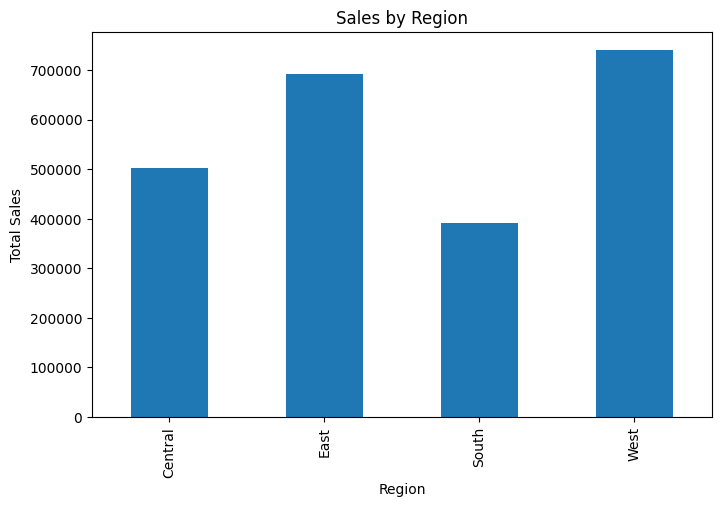

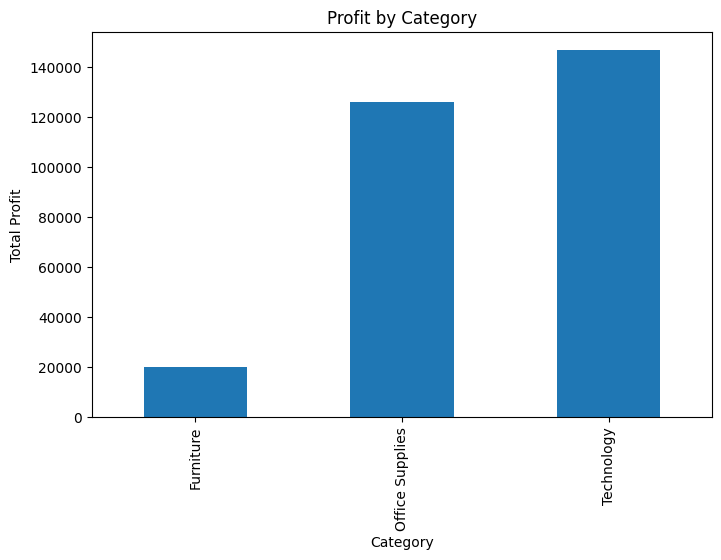

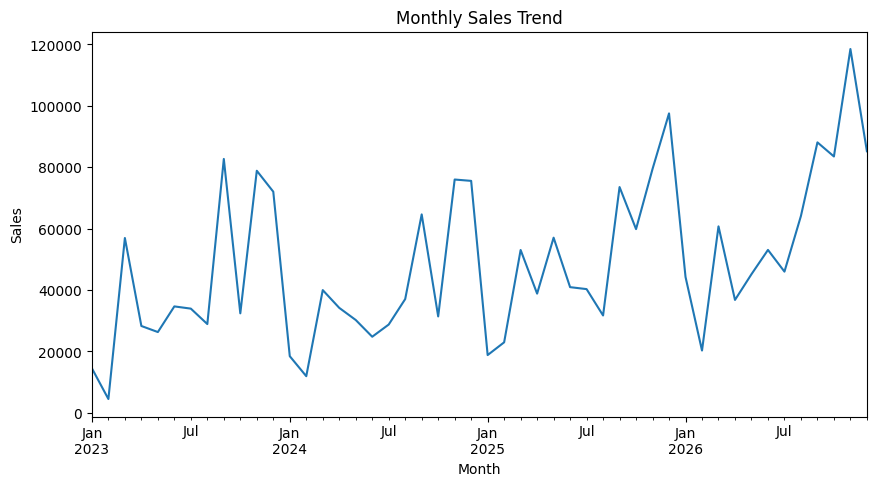

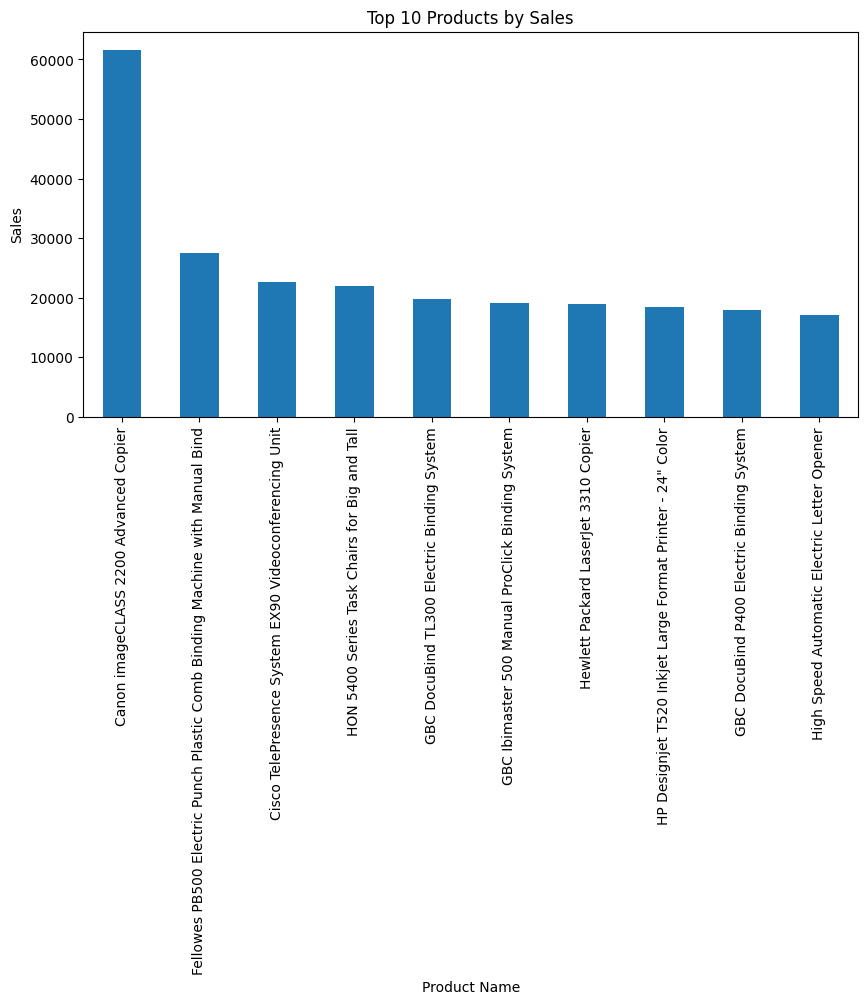

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("../data/clean_superstore_sales.csv")

# Preview dataset
print(df.head())

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# -------------------------------
# Total Sales
# -------------------------------
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

# -------------------------------
# Sales by Region
# -------------------------------
sales_region = df.groupby('Region')['Sales'].sum()

sales_region.plot(
    kind='bar',
    title="Sales by Region",
    xlabel="Region",
    ylabel="Total Sales",
    figsize=(8,5)
)

plt.show()

# -------------------------------
# Profit by Category
# -------------------------------
profit_category = df.groupby('Category')['Profit'].sum()

profit_category.plot(
    kind='bar',
    title="Profit by Category",
    xlabel="Category",
    ylabel="Total Profit",
    figsize=(8,5)
)

plt.show()

# -------------------------------
# Monthly Sales Trend
# -------------------------------
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(
    title="Monthly Sales Trend",
    xlabel="Month",
    ylabel="Sales",
    figsize=(10,5)
)

plt.show()

# -------------------------------
# Top 10 Products by Sales
# -------------------------------
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(
    kind='bar',
    title="Top 10 Products by Sales",
    xlabel="Product Name",
    ylabel="Sales",
    figsize=(10,5)
)

plt.show()